In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from datasets import load_dataset
from PIL import Image

In [ ]:
np.random.seed(42)
tf.random.set_seed(42)

print("TF version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TF version: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


### Load Dataset

In [ ]:
dataset = load_dataset("deedax/UTK-Face-Revised")
train_data = dataset["train"]
valid_data = dataset["valid"]

README.md:   0%|          | 0.00/573 [00:00<?, ?B/s]

data/train-00000-of-00001-45aaf0da287756(…):   0%|          | 0.00/352M [00:00<?, ?B/s]

data/valid-00000-of-00001-a4eb16e4d89345(…):   0%|          | 0.00/39.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/7623 [00:00<?, ? examples/s]

Generating valid split:   0%|          | 0/846 [00:00<?, ? examples/s]

In [ ]:
print("\n1.2 Dataset structure:")
print(dataset['train'])

print("\nFirst training sample:")
sample = dataset['train'][0]
print(f"Image shape: {sample['image'].size}")
print(f"Age: {sample['age']}")
print(f"Gender: {sample['gender']}")
print(f"Race: {sample['race']}")
print(f"Age Group: {sample['age_group']}")



1.2 Dataset structure:
Dataset({
    features: ['image', 'age', 'gender', 'race', 'age_group'],
    num_rows: 7623
})

First training sample:
Image shape: (200, 200)
Age: 22
Gender: Male
Race: White
Age Group: Young adult


In [ ]:
def analyze_labels(dataset_split):
    """Analyze distribution of labels"""
    ages = [sample['age'] for sample in dataset_split]
    genders = [sample['gender'] for sample in dataset_split]
    races = [sample['race'] for sample in dataset_split]
    age_groups = [sample['age_group'] for sample in dataset_split]

    return {
        'ages': ages,
        'genders': genders,
        'races': races,
        'age_groups': age_groups
    }

train_labels = analyze_labels(dataset['train'])

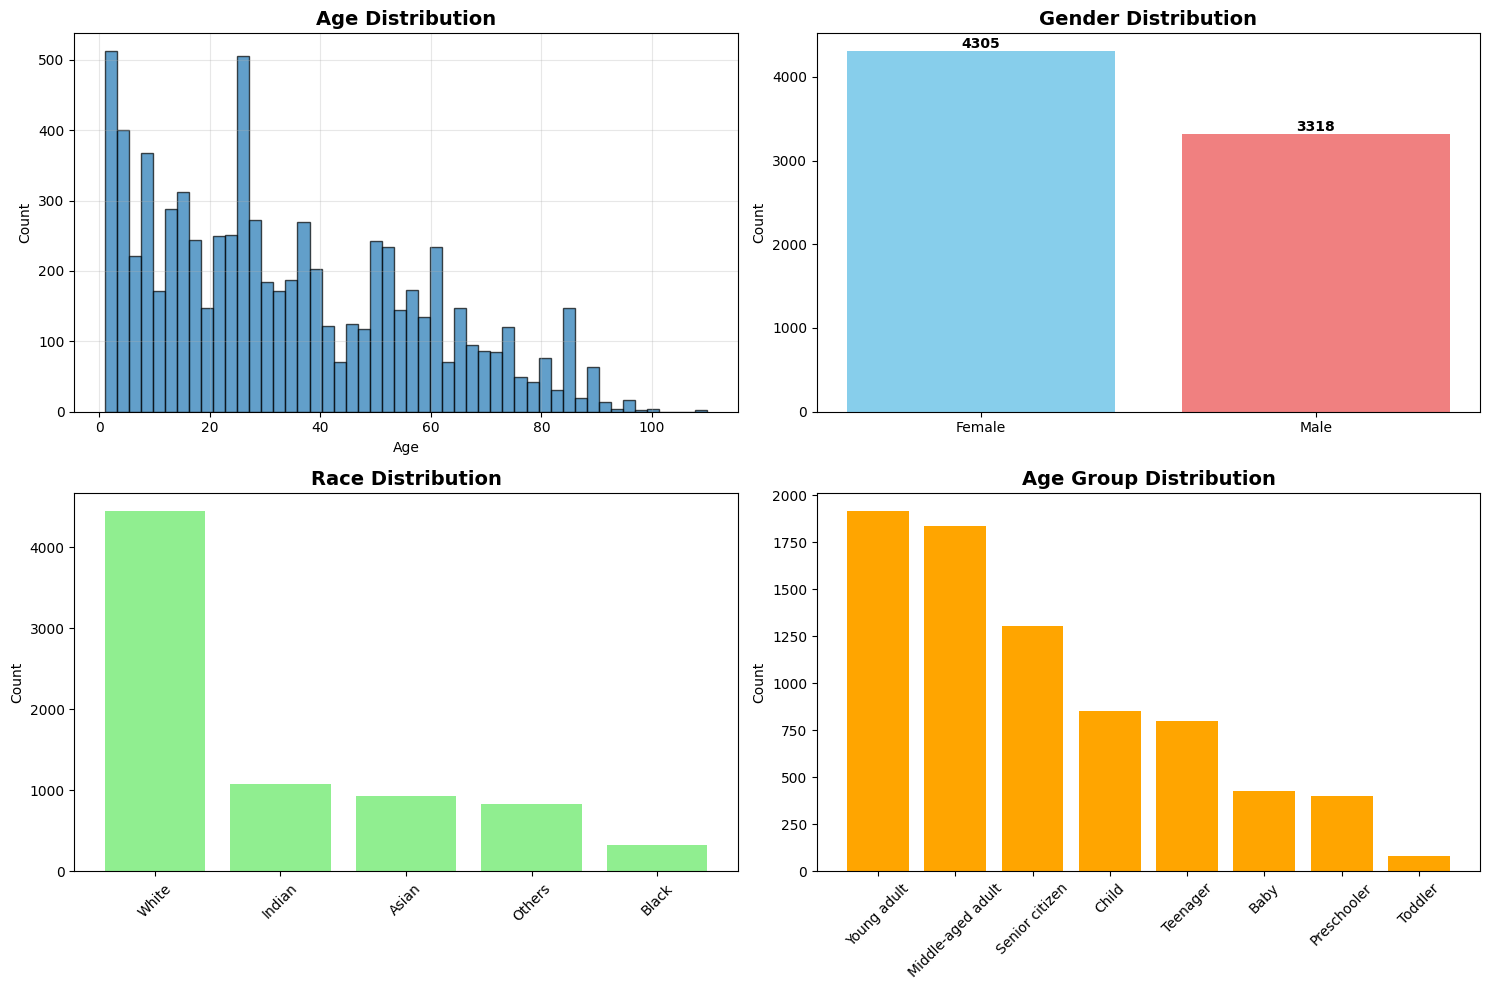

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Age distribution
axes[0, 0].hist(train_labels['ages'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Age Distribution', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Age')
axes[0, 0].set_ylabel('Count')
axes[0, 0].grid(True, alpha=0.3)

# Gender distribution
gender_counts = pd.Series(train_labels['genders']).value_counts()
axes[0, 1].bar(gender_counts.index, gender_counts.values, color=['skyblue', 'lightcoral'])
axes[0, 1].set_title('Gender Distribution', fontsize=14, fontweight='bold')
axes[0, 1].set_ylabel('Count')
for i, v in enumerate(gender_counts.values):
    axes[0, 1].text(i, v, str(v), ha='center', va='bottom', fontweight='bold')

# Race distribution
race_counts = pd.Series(train_labels['races']).value_counts()
axes[1, 0].bar(race_counts.index, race_counts.values, color='lightgreen')
axes[1, 0].set_title('Race Distribution', fontsize=14, fontweight='bold')
axes[1, 0].set_ylabel('Count')
axes[1, 0].tick_params(axis='x', rotation=45)

# Age group distribution
age_group_counts = pd.Series(train_labels['age_groups']).value_counts()
axes[1, 1].bar(age_group_counts.index, age_group_counts.values, color='orange')
axes[1, 1].set_title('Age Group Distribution', fontsize=14, fontweight='bold')
axes[1, 1].set_ylabel('Count')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()



1.4 Displaying sample images...


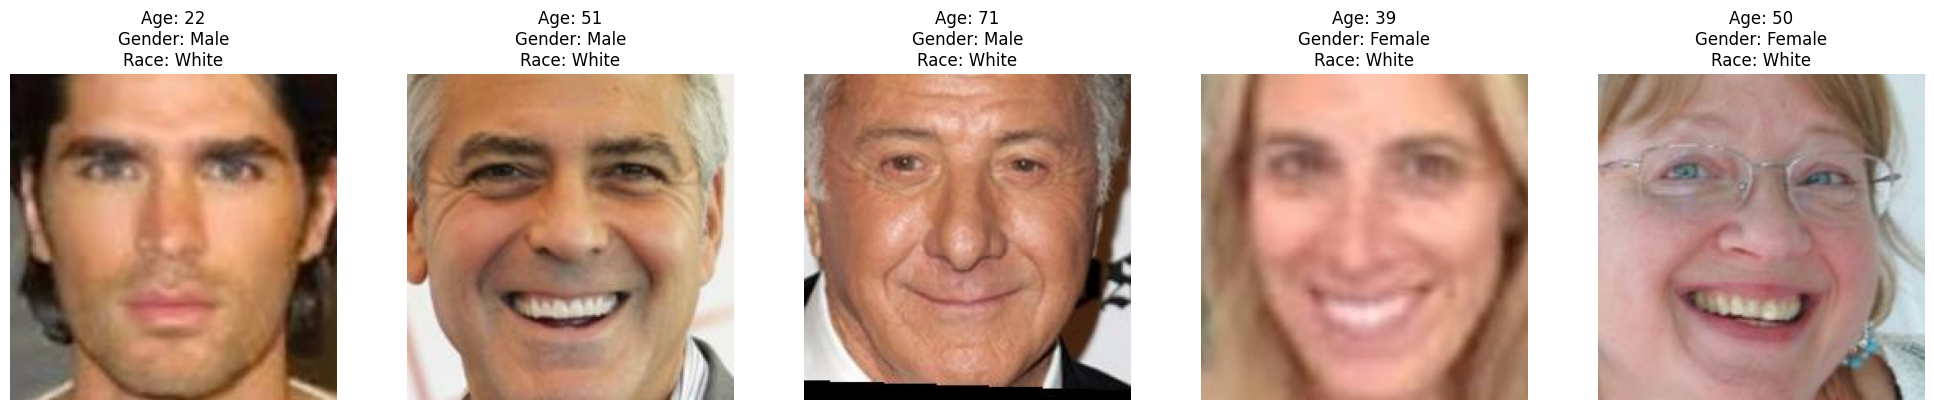

In [ ]:
print("\n1.4 Displaying sample images...")

def display_samples(dataset_split, num_samples=5):
    """Display sample images with labels"""
    fig, axes = plt.subplots(1, num_samples, figsize=(20, 4))

    for i in range(num_samples):
        sample = dataset_split[i]
        img = np.array(sample['image'])

        axes[i].imshow(img)
        axes[i].set_title(f"Age: {sample['age']}\nGender: {sample['gender']}\nRace: {sample['race']}")
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

display_samples(dataset['train'], num_samples=5)

### Augmentation


In [ ]:
augment = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.05),
], name="augment")

### Preprocessing Pipeline

In [ ]:
def to_tf_example(example):
    img = np.array(example["image"].convert("RGB").resize((224, 224)), dtype=np.uint8)
    age = np.float32(example["age"])
    return img, age

def gen_split(data):
    for ex in data:
        yield to_tf_example(ex)

output_signature = (
    tf.TensorSpec(shape=(224, 224, 3), dtype=tf.uint8),
    tf.TensorSpec(shape=(), dtype=tf.float32),
)

train_ds = tf.data.Dataset.from_generator(
    lambda: gen_split(train_data),
    output_signature=output_signature
)

valid_ds = tf.data.Dataset.from_generator(
    lambda: gen_split(valid_data),
    output_signature=output_signature
)

def preprocess_batch(img, age, training=False):
    img = tf.cast(img, tf.float32)
    if training:
        img = augment(img, training=True)
    img = preprocess_input(img)
    return img, age

train_ds = (
    train_ds
    .shuffle(2048, seed=42, reshuffle_each_iteration=True)
    .map(lambda x, y: preprocess_batch(x, y, training=True), num_parallel_calls=tf.data.AUTOTUNE)
    .batch(32)
    .prefetch(tf.data.AUTOTUNE)
)

valid_ds = (
    valid_ds
    .map(lambda x, y: preprocess_batch(x, y, training=False), num_parallel_calls=tf.data.AUTOTUNE)
    .batch(32)
    .prefetch(tf.data.AUTOTUNE)
)


### Model Architecture

In [ ]:
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)
base_model.trainable = False  # Stage 1

inputs = keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)

x = layers.Dense(256, activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)

x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(1, activation="linear")(x)
model = keras.Model(inputs, outputs)
model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,146,305 (92.11 MB)

 Trainable params: 558,081 (2.13 MB)

 Non-trainable params: 23,588,224 (89.98 MB)

### Train Stage 1 (head only)

In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss=keras.losses.Huber(),
    metrics=[keras.metrics.MeanAbsoluteError(name="mae")]
)

callbacks = [
    EarlyStopping(patience=6, restore_best_weights=True),
    ReduceLROnPlateau(patience=3, factor=0.3)
]

history_1 = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=15,
    callbacks=callbacks
)

Epoch 1/15
239/239 ━━━━━━━━━━━━━━━━━━━━ 143s 502ms/step - loss: 31.3606 - mae: 31.8559 - val_loss: 21.9558 - val_mae: 22.4416 - learning_rate: 1.0000e-04
Epoch 2/15
239/239 ━━━━━━━━━━━━━━━━━━━━ 122s 454ms/step - loss: 20.6433 - mae: 21.1334 - val_loss: 11.0967 - val_mae: 11.5841 - learning_rate: 1.0000e-04
Epoch 3/15
239/239 ━━━━━━━━━━━━━━━━━━━━ 167s 670ms/step - loss: 12.4820 - mae: 12.9693 - val_loss: 8.6830 - val_mae: 9.1656 - learning_rate: 1.0000e-04
Epoch 4/15
239/239 ━━━━━━━━━━━━━━━━━━━━ 141s 559ms/step - loss: 10.2605 - mae: 10.7474 - val_loss: 8.0560 - val_mae: 8.5345 - learning_rate: 1.0000e-04
Epoch 5/15
239/239 ━━━━━━━━━━━━━━━━━━━━ 115s 452ms/step - loss: 9.7282 - mae: 10.2123 - val_loss: 7.7323 - val_mae: 8.2145 - learning_rate: 1.0000e-04
Epoch 6/15
239/239 ━━━━━━━━━━━━━━━━━━━━ 116s 455ms/step - loss: 9.1541 - mae: 9.6363 - val_loss: 7.7441 - val_mae: 8.2232 - learning_rate: 1.0000e-04
Epoch 7/15
239/239 ━━━━━━━━━━━━━━━━━━━━ 115s 453ms/step - loss: 9.0275 - mae: 9.5119 - 

### Train Stage 2 (fine-tune)

In [ ]:
base_model.trainable = True # stage 2
FINE_TUNE_LAST_N = 50

for layer in base_model.layers[:-FINE_TUNE_LAST_N]:
    layer.trainable = False

# keep BN frozen
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss=keras.losses.Huber(),
    metrics=[keras.metrics.MeanAbsoluteError(name="mae")]
)

history_2 = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=30,
    callbacks=callbacks
)

Epoch 1/30
239/239 ━━━━━━━━━━━━━━━━━━━━ 156s 539ms/step - loss: 8.3838 - mae: 8.8648 - val_loss: 6.5183 - val_mae: 6.9935 - learning_rate: 1.0000e-05
Epoch 2/30
239/239 ━━━━━━━━━━━━━━━━━━━━ 123s 486ms/step - loss: 7.6472 - mae: 8.1267 - val_loss: 6.3392 - val_mae: 6.8140 - learning_rate: 1.0000e-05
Epoch 3/30
239/239 ━━━━━━━━━━━━━━━━━━━━ 141s 563ms/step - loss: 7.4816 - mae: 7.9613 - val_loss: 6.2669 - val_mae: 6.7411 - learning_rate: 1.0000e-05
Epoch 4/30
239/239 ━━━━━━━━━━━━━━━━━━━━ 122s 481ms/step - loss: 7.2618 - mae: 7.7392 - val_loss: 6.1575 - val_mae: 6.6315 - learning_rate: 1.0000e-05
Epoch 5/30
239/239 ━━━━━━━━━━━━━━━━━━━━ 122s 480ms/step - loss: 7.1808 - mae: 7.6601 - val_loss: 5.9027 - val_mae: 6.3780 - learning_rate: 1.0000e-05
Epoch 6/30
239/239 ━━━━━━━━━━━━━━━━━━━━ 143s 567ms/step - loss: 6.7232 - mae: 7.1997 - val_loss: 5.6841 - val_mae: 6.1567 - learning_rate: 1.0000e-05
Epoch 7/30
239/239 ━━━━━━━━━━━━━━━━━━━━ 122s 482ms/step - loss: 6.7438 - mae: 7.2213 - val_loss: 5.5

### Evaluation

In [ ]:
preds = model.predict(valid_ds).reshape(-1)
true_ages = np.array([float(ex["age"]) for ex in valid_data], dtype=np.float32)

mae = np.mean(np.abs(preds - true_ages))
rmse = np.sqrt(np.mean((preds - true_ages) ** 2))
print(f"VALID MAE:  {mae:.2f} years")
print(f"VALID RMSE: {rmse:.2f} years")
print("Pred stats:", preds.min(), preds.max(), preds.mean(), preds.std())

27/27 ━━━━━━━━━━━━━━━━━━━━ 19s 406ms/step
VALID MAE:  5.64 years
VALID RMSE: 8.01 years
Pred stats: 0.49551266 102.27772 33.592587 22.762426


In [ ]:
# Save Model
model.save('age_prediction_model.keras')
print("Model saved as 'age_prediction_model.keras'")

Model saved as 'age_prediction_model.keras'


In [ ]:
model = keras.models.load_model('age_prediction_model.keras')

### Test Pipeline




In [ ]:
import mediapipe as mp
print(mp)
print(mp.__file__)
print(dir(mp))

<module 'mediapipe' from '/usr/local/lib/python3.12/dist-packages/mediapipe/__init__.py'>
/usr/local/lib/python3.12/dist-packages/mediapipe/__init__.py
['Image', 'ImageFormat', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '__version__', 'tasks']


In [ ]:
import mediapipe as mp
import numpy as np
from PIL import Image

BaseOptions = mp.tasks.BaseOptions
FaceDetector = mp.tasks.vision.FaceDetector
FaceDetectorOptions = mp.tasks.vision.FaceDetectorOptions
VisionRunningMode = mp.tasks.vision.RunningMode

def detect_and_crop_face_pil(pil_img, margin=0.5, min_score=0.5):
    img = np.array(pil_img.convert("RGB"))
    h, w, _ = img.shape

    options = FaceDetectorOptions(
        base_options=BaseOptions(model_asset_path=None),
        running_mode=VisionRunningMode.IMAGE
    )

    with FaceDetector.create_from_options(options) as detector:
        mp_img = mp.Image(image_format=mp.ImageFormat.SRGB, data=img)
        result = detector.detect(mp_img)

    if not result.detections:
        return None, None, None

    # pick best detection
    det = max(result.detections, key=lambda d: d.categories[0].score)
    score = det.categories[0].score

    if score < min_score:
        return None, None, None

    bbox = det.bounding_box

    # expand bounding box (VERY IMPORTANT for age models)
    mx = int(bbox.width * margin)
    my = int(bbox.height * margin)

    x1 = max(0, bbox.origin_x - mx)
    y1 = max(0, bbox.origin_y - my)
    x2 = min(w, bbox.origin_x + bbox.width + mx)
    y2 = min(h, bbox.origin_y + bbox.height + my)

    face = Image.fromarray(img[y1:y2, x1:x2])
    return face, (x1, y1, x2, y2), score

In [ ]:
def predict_age_from_pil_face(face_pil):

    face = face_pil.convert("RGB").resize((224, 224))
    arr = np.array(face, dtype=np.float32)
    arr = preprocess_input(arr)
    arr = np.expand_dims(arr, axis=0)
    pred = float(model.predict(arr, verbose=0)[0][0])
    return max(0.0, pred)

In [ ]:
def predict_image_with_face_crop(img_path, margin=0.35, min_score=0.5, show_debug=True):

    pil_img = Image.open(img_path).convert("RGB")

    face, bbox, score = detect_and_crop_face_pil(
        pil_img, margin=margin, min_score=min_score
    )

    if face is None:
        # fallback: try predicting on whole image (not recommended)
        whole = pil_img.resize((224, 224))
        arr = preprocess_input(np.array(whole, dtype=np.float32))
        pred = float(model.predict(arr[None, ...], verbose=0)[0][0])
        pred = max(0.0, pred)

        plt.figure(figsize=(6, 6))
        plt.imshow(pil_img)
        plt.title(f"[NO FACE FOUND] Pred (whole img): {pred:.1f}")
        plt.axis("off")
        plt.show()
        return pred

    pred = predict_age_from_pil_face(face)

    if show_debug:
        # show original + bbox + cropped face
        fig = plt.figure(figsize=(12, 5))

        ax1 = plt.subplot(1, 2, 1)
        ax1.imshow(pil_img)
        x1, y1, x2, y2 = bbox
        ax1.add_patch(plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, linewidth=2))
        ax1.set_title(f"Detected face (score={score:.2f})")
        ax1.axis("off")

        ax2 = plt.subplot(1, 2, 2)
        ax2.imshow(face)
        ax2.set_title(f"Predicted Age: {pred:.1f}")
        ax2.axis("off")

        plt.show()

    return pred

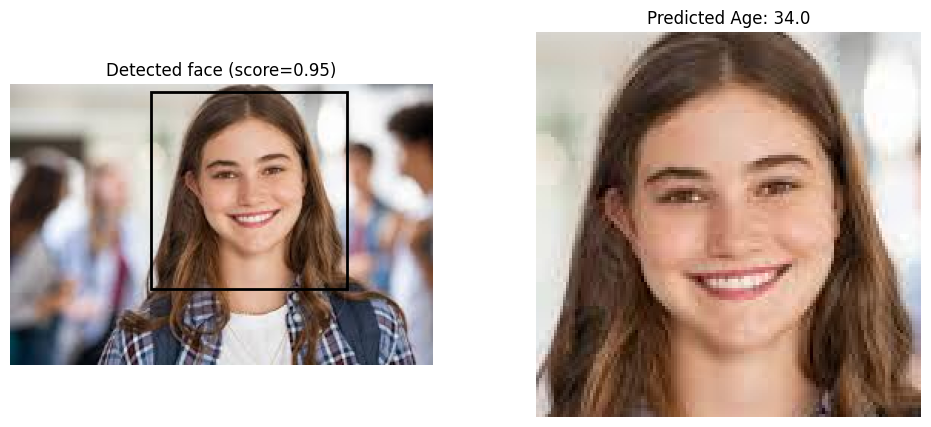

34.003902435302734

In [ ]:
predict_image_with_face_crop('/content/download (2).jpg')

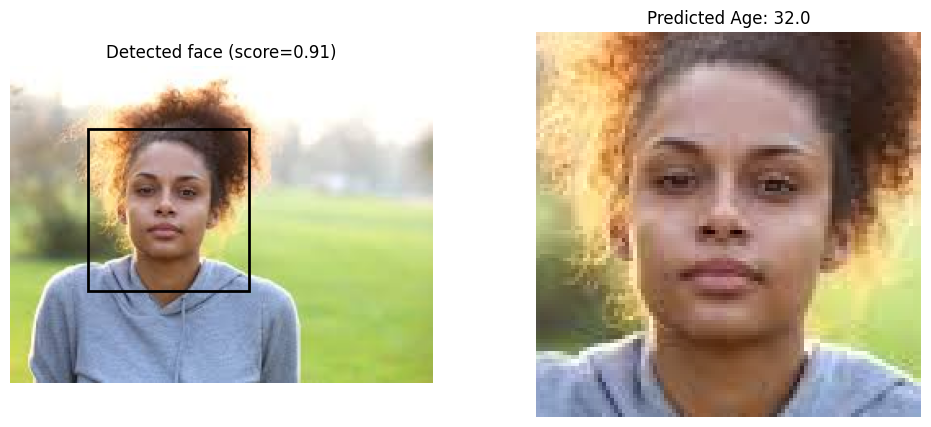

31.96483612060547

In [ ]:
predict_image_with_face_crop('/content/download (4).jpg')

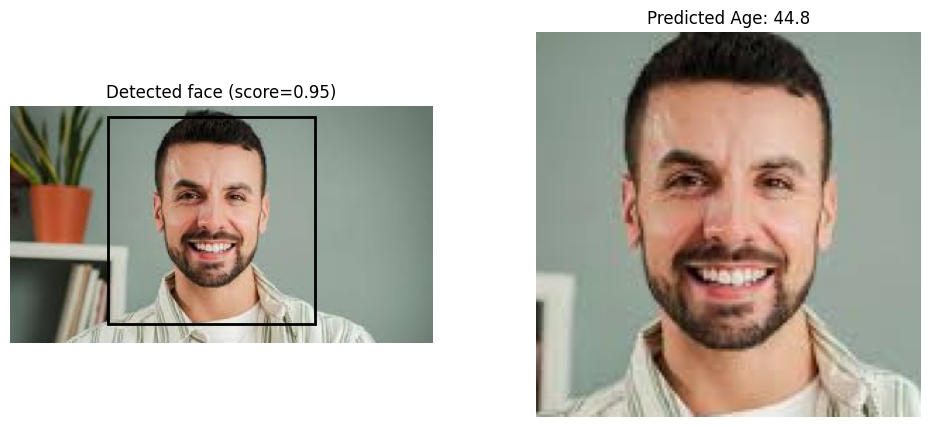

44.80385971069336

In [ ]:
predict_image_with_face_crop('/content/download (5).jpg')

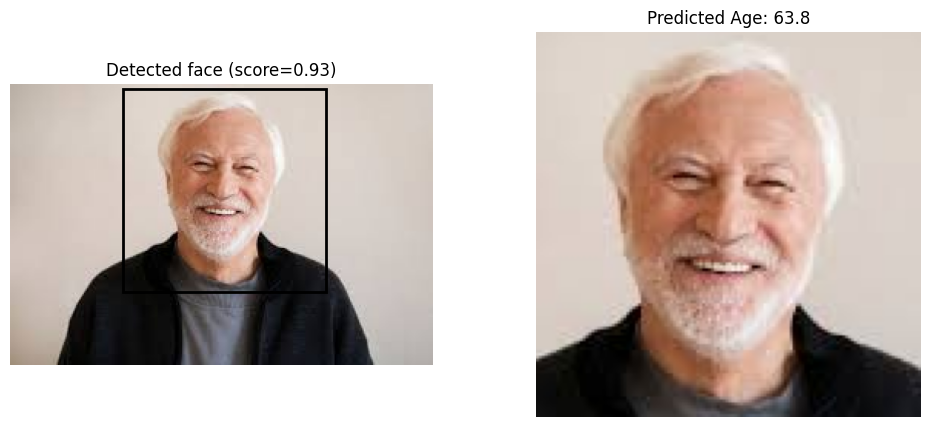

63.796730041503906

In [ ]:
predict_image_with_face_crop('/content/download (7).jpg')

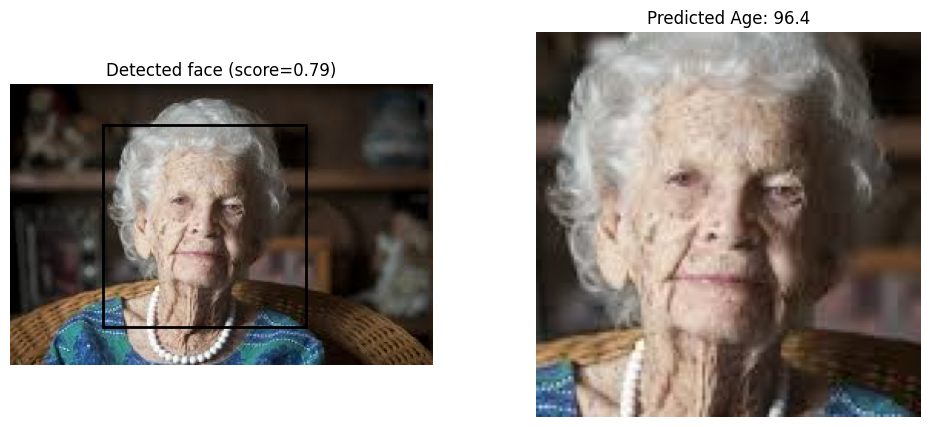

96.39677429199219

In [ ]:
predict_image_with_face_crop('/content/download.jpg')

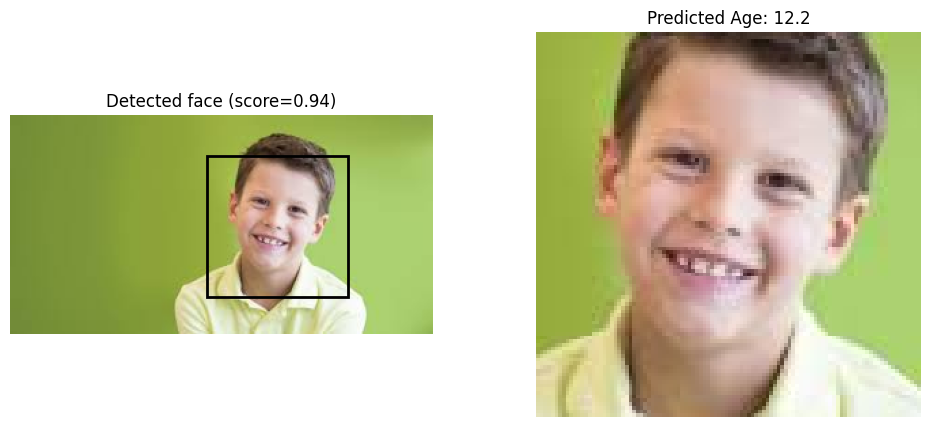

12.1658296585083

In [ ]:
predict_image_with_face_crop('/content/images.jpg')

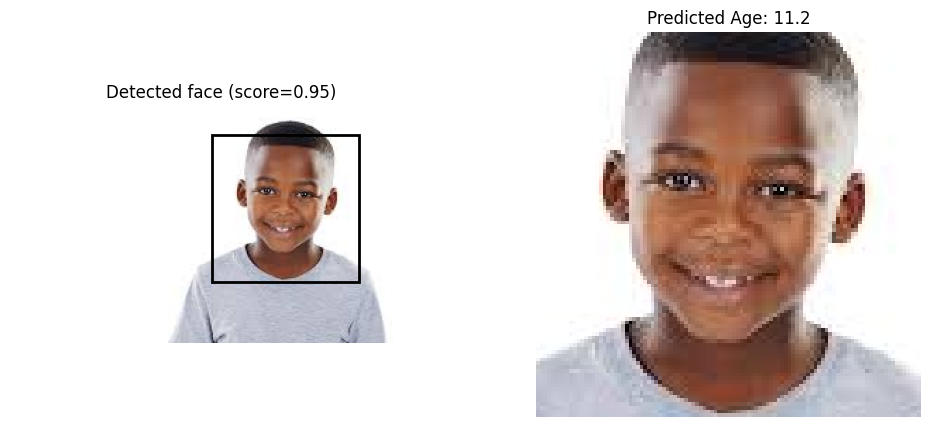

11.22453784942627

In [ ]:
predict_image_with_face_crop('/content/images.jpg')

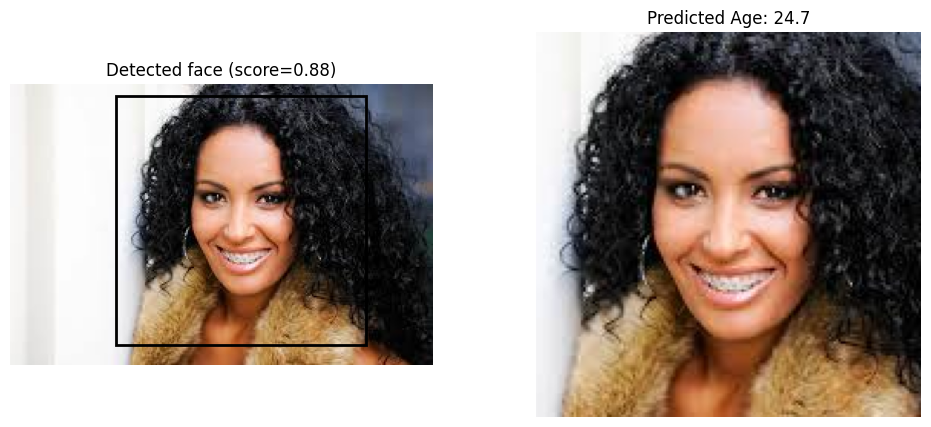

24.683795928955078

In [ ]:
predict_image_with_face_crop('/content/download.jpg')

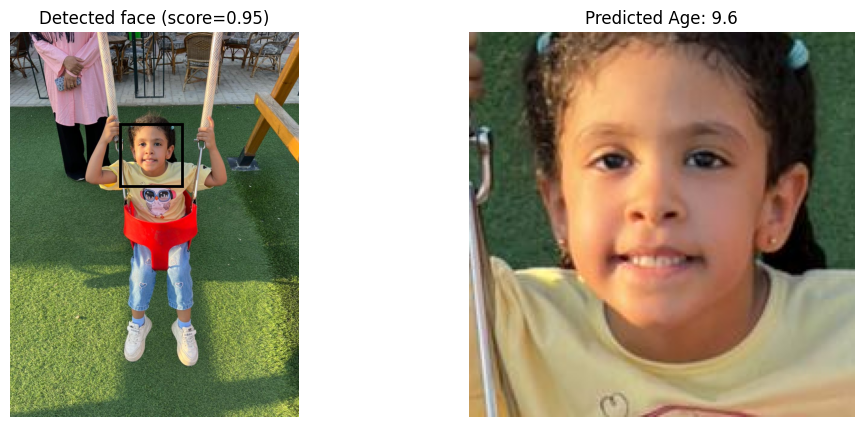

9.606781005859375

In [ ]:
predict_image_with_face_crop('/content/1.jpg')